In [1]:
from langgraph.store.memory import InMemoryStore

In [2]:
# creating a store
store = InMemoryStore()

In [3]:
# creating a namespace
namespace = ("user", "u1")

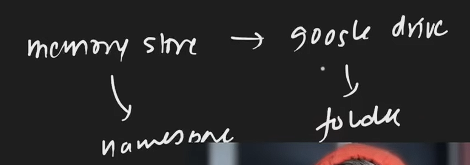

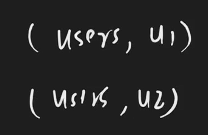
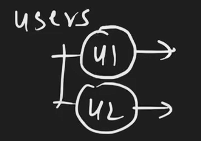

Creating Memories

In [4]:
# Adding memories
store.put(namespace, "1", {"data" : "User like pizza"})  # (namespace, unique key, value)
store.put(namespace, "2", {"data" : "User prefer dark mode"})

In [5]:
# another namespace
namespace2 = ("user", "u2")

# adding memories in another namespace
store.put(namespace2, "1", {"data" : "user likes pasta"})
store.put(namespace2, "2", {"data" : "User prefers grid style navigation"})

Retrieving Memories

In [6]:
# store.get(namespace, key)
store.get(namespace, "1")

Item(namespace=['user', 'u1'], key='1', value={'data': 'User like pizza'}, created_at='2026-01-15T07:54:39.750112+00:00', updated_at='2026-01-15T07:54:39.750112+00:00')

In [7]:
store.get(namespace2, "1")

Item(namespace=['user', 'u2'], key='1', value={'data': 'user likes pasta'}, created_at='2026-01-15T07:57:29.558192+00:00', updated_at='2026-01-15T07:57:29.558192+00:00')

In [8]:
# retrieving all memories
items = store.search(namespace)

for item in items:
      print(item.value)

{'data': 'User like pizza'}
{'data': 'User prefer dark mode'}


In [9]:
# retrieving all memories
items = store.search(namespace2)

for item in items:
      print(item.value)

{'data': 'user likes pasta'}
{'data': 'User prefers grid style navigation'}


Sementic Search - searching based on the context and its meaning

In [19]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langgraph.store.memory import InMemoryStore
from dotenv import load_dotenv
load_dotenv()

True

In [20]:
embedding_model = GoogleGenerativeAIEmbeddings(model="models/text-embedding-004")

In [21]:
store = InMemoryStore(index = {'embed' : embedding_model, 'dims' : 1536})

In [22]:
namespace = ("user", "u3")

In [23]:
store.put(namespace, "1", {"data": "User prefers concise answers over long explanations"})
store.put(namespace, "2", {"data": "User likes examples in Python"})
store.put(namespace, "3", {"data": "User usually works late at night"})
store.put(namespace, "4", {"data": "User prefers dark mode in applications"})
store.put(namespace, "5", {"data": "User is learning machine learning"})
store.put(namespace, "6", {"data": "User dislikes overly theoretical explanations"})
store.put(namespace, "7", {"data": "User prefers step-by-step reasoning"})
store.put(namespace, "8", {"data": "User is based in India"})
store.put(namespace, "9", {"data": "User likes real-world analogies"})
store.put(namespace, "10", {"data": "User prefers bullet points over paragraphs"})

In [26]:
items = store.search(namespace, query = "what is the user currently learnig", limit = 1)

for item in items:
      print(item.value)

{'data': 'User is learning machine learning'}


In [27]:
items = store.search(namespace, query = "what is the user prefers related to coding language", limit = 5)

for item in items:
      print(item.value)

{'data': 'User prefers bullet points over paragraphs'}
{'data': 'User prefers concise answers over long explanations'}
{'data': 'User prefers step-by-step reasoning'}
{'data': 'User prefers dark mode in applications'}
{'data': 'User likes real-world analogies'}


In [30]:
items = store.search(namespace, query = "what is the user preferences", limit = 4)

for item in items:
      print(item.value)

{'data': 'User prefers dark mode in applications'}
{'data': 'User prefers bullet points over paragraphs'}
{'data': 'User usually works late at night'}
{'data': 'User prefers concise answers over long explanations'}
